In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Preprocessing ENTSO dataset

In [2]:
path_rawdata_directory = "../datasets_raw/"

# Time series actual offshore energy production

In [3]:
path = path_rawdata_directory + "ENTSO_timeseries/"
raw_filenames = [f for f in os.listdir(path)]

# End product with a time series and total offshore power
df_full_timeseries = pd.DataFrame()

for file in raw_filenames:
    df = pd.read_csv(path + file, low_memory=False)

    # Filter for Offshore Wind only
    df = df[df["Production Type"] == "Wind Offshore"]

    # Extract just the start time from the range string
    df["Datetime"] = pd.to_datetime(
        df["MTU (CET/CEST)"]
        .str.split(" - ").str[0]
        .str.replace(r"\(.*?\)", "", regex=True)
        .str.strip(),
        dayfirst=True
    )

    # Keep only needed columns
    df = df[["Datetime", "Generation (MW)"]]

    # rename for better consistency
    df.rename(columns={"Generation (MW)": "Generation_MW"}, inplace=True)
    #convert to numeric data
    df["Generation_MW"] = pd.to_numeric(df["Generation_MW"], errors="coerce")

    # check if file is completely empty (None or 0 values)
    if (df["Generation_MW"].fillna(0) == 0).all():
        print(f"Skipping {file} -- no valid data")
        continue

    # Set datetime as index
    df = df.set_index("Datetime")

    # Resample to hourly timestamps
    df = df.resample("h").mean()

    #Append to full time series df
    df_full_timeseries = pd.concat([df_full_timeseries, df])


Skipping AGGREGATED_GENERATION_PER_TYPE_GENERATION_201312312300-201412312300.csv -- no valid data


In [4]:
df_full_timeseries

,Generation_MW
Datetime,
2015-01-01 00:00:00,96.8125
2015-01-01 01:00:00,95.0725
2015-01-01 02:00:00,95.8175
2015-01-01 03:00:00,95.2375
2015-01-01 04:00:00,84.2800
...,...
2026-12-31 19:00:00,NaN
2026-12-31 20:00:00,NaN
2026-12-31 21:00:00,NaN


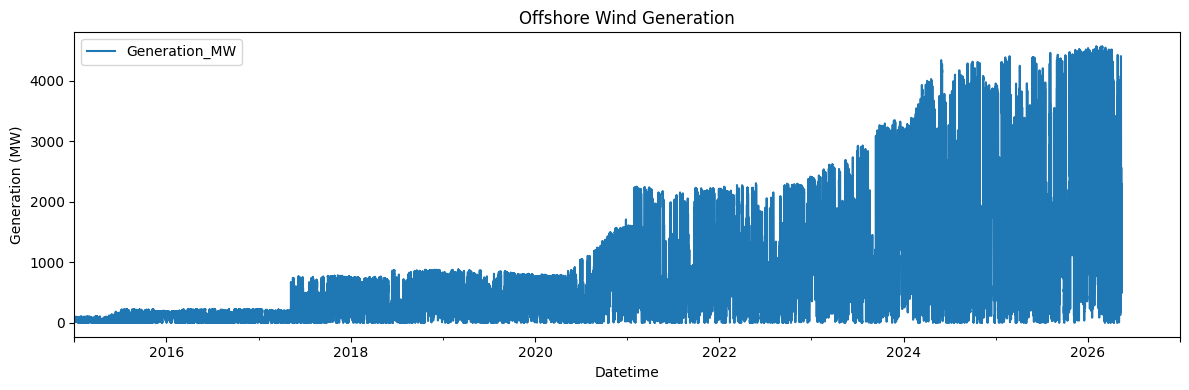

In [5]:
# Quality check plot:
df_full_timeseries.plot(figsize=(12, 4))
plt.title("Offshore Wind Generation")
plt.ylabel("Generation (MW)")
plt.xlabel("Datetime")
plt.tight_layout()
plt.show()

In [6]:
# For incomplete year (days in the future), search for last valid entry and drop that day and consecutive days
last_valid = df_full_timeseries["Generation_MW"].last_valid_index()
if last_valid:
    last_valid_day = last_valid.date()
    df_full_timeseries = df_full_timeseries[df_full_timeseries.index.date < last_valid_day]

In [7]:
df_full_timeseries.isna().sum()

Generation_MW    12
dtype: int64

In [8]:
df_full_timeseries[df_full_timeseries.isna().any(axis=1)]

,Generation_MW
Datetime,
2015-03-29 02:00:00,NaN
2016-03-27 02:00:00,NaN
2017-03-26 02:00:00,NaN
2018-03-25 02:00:00,NaN
2019-03-31 02:00:00,NaN
2020-03-29 02:00:00,NaN
2021-03-28 02:00:00,NaN
2022-03-27 02:00:00,NaN
2023-03-26 02:00:00,NaN


In [9]:
#forward fill daylight saving times
df_full_timeseries = df_full_timeseries.ffill(limit=1)

In [10]:
df_full_timeseries.to_csv("../datasets/ENTSOE_power_time_series.csv")